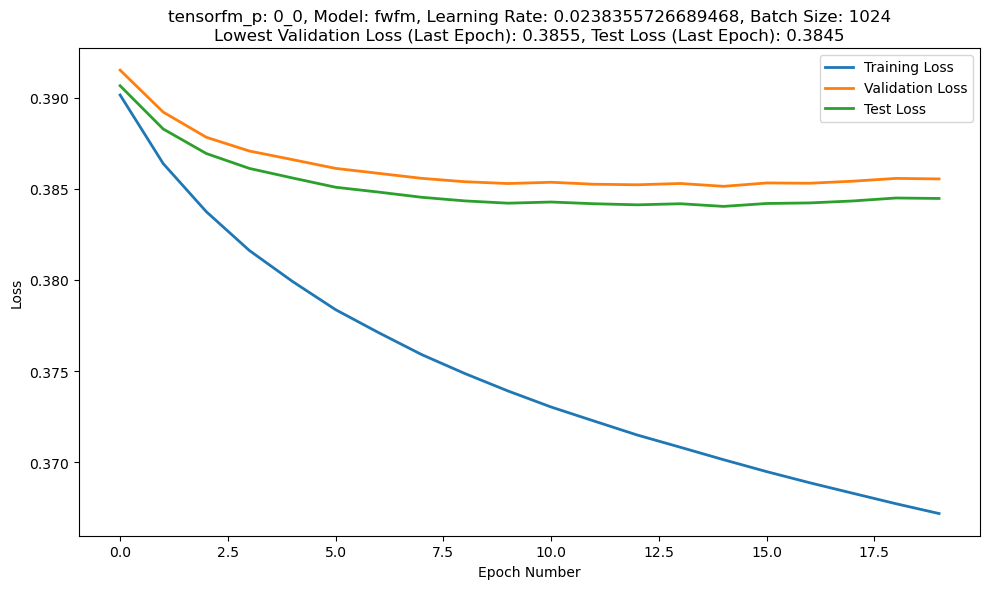

In [2]:
import pandas as pd
import matplotlib.pyplot as plt


file_path = 'optuna_all.txt'  # Replace with your actual file path
df = pd.read_csv(file_path, delimiter=',',header=None)
# Sample column list for reference
columns = ['Study','model name','metric to optimize','rank','embed. size','learning rate',
           'optimizer','batch size','tensorfm_p','return_L2','coef vectors','coef biases',
           'part id','trial number','epoch number','train loss','train auc','validation loss',
           'validation auc','test loss','test auc','epoch train time','validation time',
           'criterion','dataset']
df.columns = columns

df_logloss = df[df['metric to optimize'] == 'logloss']


last_epoch_df = df_logloss.groupby([
    'Study', 'model name', 'metric to optimize', 'rank', 'embed. size',
    'learning rate', 'optimizer', 'batch size', 'tensorfm_p'
])['epoch number'].max().reset_index()

last_epoch_data = pd.merge(df_logloss, last_epoch_df, on=[
    'Study', 'model name', 'metric to optimize', 'rank', 'embed. size',
    'learning rate', 'optimizer', 'batch size', 'tensorfm_p', 'epoch number'
])


lowest_val_loss_models = last_epoch_data.loc[last_epoch_data.groupby('tensorfm_p')['validation loss'].idxmin()]


for _, row in lowest_val_loss_models.iterrows():

    model_data = df_logloss[
        (df_logloss['Study'] == row['Study']) &
        (df_logloss['model name'] == row['model name']) &
        (df_logloss['metric to optimize'] == row['metric to optimize']) &
        (df_logloss['rank'] == row['rank']) &
        (df_logloss['embed. size'] == row['embed. size']) &
        (df_logloss['learning rate'] == row['learning rate']) &
        (df_logloss['optimizer'] == row['optimizer']) &
        (df_logloss['batch size'] == row['batch size']) &
        (df_logloss['tensorfm_p'] == row['tensorfm_p']) &
        (df_logloss['coef vectors'] == row['coef vectors']) &
        (df_logloss['coef biases'] == row['coef biases'])
    ]

    last_epoch_test_loss = row['test loss']


    plt.figure(figsize=(10, 6))
    plt.plot(model_data['epoch number'], model_data['train loss'], label='Training Loss', linewidth=2)
    plt.plot(model_data['epoch number'], model_data['validation loss'], label='Validation Loss', linewidth=2)
    plt.plot(model_data['epoch number'], model_data['test loss'], label='Test Loss', linewidth=2)


    plt.xlabel('Epoch Number')
    plt.ylabel('Loss')
    plt.title(f"tensorfm_p: {row['tensorfm_p']}, Model: {row['model name']}, "
              f"Learning Rate: {row['learning rate']}, Batch Size: {row['batch size']}\n"
              f"Lowest Validation Loss (Last Epoch): {row['validation loss']:.4f}, "
              f"Test Loss (Last Epoch): {last_epoch_test_loss:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.show()


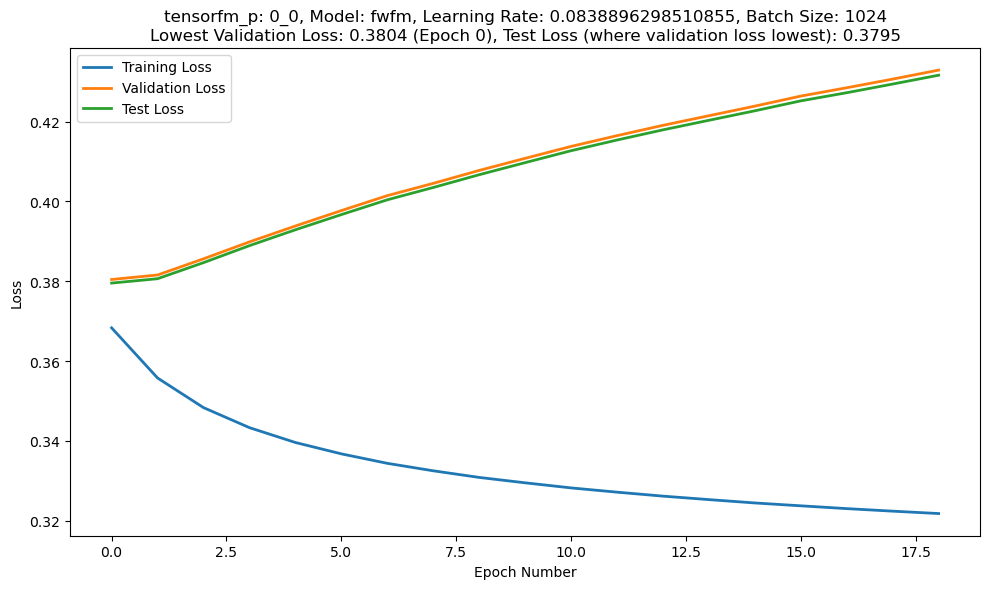

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your dataset
# df = pd.read_csv('your_dataset.csv')
file_path = 'optuna_all.txt' 
df = pd.read_csv(file_path, delimiter=',',header=None)

columns = ['Study','model name','metric to optimize','rank','embed. size','learning rate',
           'optimizer','batch size','tensorfm_p','return_L2','coef vectors','coef biases',
           'part id','trial number','epoch number','train loss','train auc','validation loss',
           'validation auc','test loss','test auc','epoch train time','validation time',
           'criterion','dataset']
df.columns = columns


df_logloss = df[df['metric to optimize'] == 'logloss']

lowest_val_loss_models = df_logloss.loc[df_logloss.groupby('tensorfm_p')['validation loss'].idxmin()]


for _, row in lowest_val_loss_models.iterrows():
    model_data = df_logloss[
        (df_logloss['Study'] == row['Study']) &
        (df_logloss['model name'] == row['model name']) &
        (df_logloss['metric to optimize'] == row['metric to optimize']) &
        (df_logloss['rank'] == row['rank']) &
        (df_logloss['embed. size'] == row['embed. size']) &
        (df_logloss['learning rate'] == row['learning rate']) &
        (df_logloss['optimizer'] == row['optimizer']) &
        (df_logloss['batch size'] == row['batch size']) &
        (df_logloss['tensorfm_p'] == row['tensorfm_p']) &
        (df_logloss['coef vectors'] == row['coef vectors']) &
        (df_logloss['coef biases'] == row['coef biases'])
    ]

    lowest_validation_epoch = row['epoch number']
    test_loss_at_lowest_val = row['test loss']

    # Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(model_data['epoch number'], model_data['train loss'], label='Training Loss', linewidth=2)
    plt.plot(model_data['epoch number'], model_data['validation loss'], label='Validation Loss', linewidth=2)
    plt.plot(model_data['epoch number'], model_data['test loss'], label='Test Loss', linewidth=2)

    # Set plot details
    plt.xlabel('Epoch Number')
    plt.ylabel('Loss')
    plt.title(f"tensorfm_p: {row['tensorfm_p']}, Model: {row['model name']}, "
              f"Learning Rate: {row['learning rate']}, Batch Size: {row['batch size']}\n"
              f"Lowest Validation Loss: {row['validation loss']:.4f} (Epoch {lowest_validation_epoch}), "
              f"Test Loss (where validation loss lowest): {test_loss_at_lowest_val:.4f}")
    plt.legend()
    plt.tight_layout()
    plt.show()